# CFD analysis of unsteady couette flow

> Two very large parallel plates, with an incompressible fluid in the space between them, are
separated by a distance h. One of the plates is suddenly accelerated from rest and moves at a
constant velocity Uo while maintaining the same distance from the other plate, which remains
stationary. The following governing equation describes the development of the fluid velocity
profile in the direction perpendicular to the plates with time:




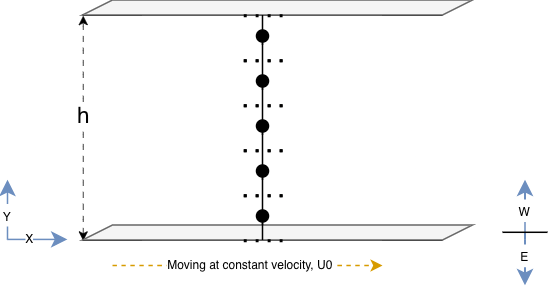

The governing equation for Couette flow is given below.

<div align="left">

$
\displaystyle
\begin{aligned}
\frac{\partial u}{\partial t} &= \nu \frac{\partial^2 u}{\partial y^2}
\qquad
\left\{
\begin{aligned}
u(y, t \le 0) &= 0 \quad && \text{for all } y \\
u(0, t) &= 0 \quad && \text{for } t > 0 \\
u(h, t) &= U_0 \quad && \text{for } t > 0
\end{aligned}
\right.
\end{aligned}
$

</div>



| Symbol | Meaning |
|-------|---------|
| $\nu$ | Kinematic viscosity |
| $u$   | Fluid velocity parallel to the plates |
| $t$   | Time |
| $y$   | Distance perpendicular to the plates |
| $U_0$ | Velocity of the upper plate |
| $h$   | Distance between the plates |



## Interior Control Volume Discretisation with θ-Method

The governing equation is:

$$
\frac{\partial u}{\partial t}
=
\nu \frac{\partial^2 u}{\partial y^2}
$$

Integrating over the control volume:

$$
y \in
\left[
y_P - \frac{\Delta y}{2},
\;
y_P + \frac{\Delta y}{2}
\right]
$$

and over timestep:

$$
t \in [t^n,\; t^{n+1}]
$$

gives:

$$
\Delta y
\left(
u_P^{n+1} - u_P^n
\right)
=
\nu
\int_{t^n}^{t^{n+1}}
\left[
\left(\frac{\partial u}{\partial y}\right)_e
-
\left(\frac{\partial u}{\partial y}\right)_w
\right]
dt
$$

The θ-method approximates the time integral as a weighted average:

$$
\int_{t^n}^{t^{n+1}} f(t)\,dt
=
\Delta t
\left[
\theta f^{n+1}
+
(1-\theta) f^n
\right]
$$

Applying this to the diffusion term:

$$
\Delta y
\left(
u_P^{n+1} - u_P^n
\right)
=
\nu \Delta t
\left[
\theta
\left(
\left(\frac{\partial u}{\partial y}\right)_e^{n+1}
-
\left(\frac{\partial u}{\partial y}\right)_w^{n+1}
\right)
+
(1-\theta)
\left(
\left(\frac{\partial u}{\partial y}\right)_e^{n}
-
\left(\frac{\partial u}{\partial y}\right)_w^{n}
\right)
\right]
$$

Using central differences:

$$
\left(\frac{\partial u}{\partial y}\right)_e
=
\frac{u_E - u_P}{\Delta y}
$$

$$
\left(\frac{\partial u}{\partial y}\right)_w
=
\frac{u_P - u_W}{\Delta y}
$$

Substituting:

$$
\Delta y
\left(
u_P^{n+1} - u_P^n
\right)
=
\frac{\nu \Delta t}{\Delta y}
\left[
\theta
\left(
u_E^{n+1} - 2u_P^{n+1} + u_W^{n+1}
\right)
+
(1-\theta)
\left(
u_E^{n} - 2u_P^{n} + u_W^{n}
\right)
\right]
$$

Dividing by $$\Delta y$$:

$$
u_P^{n+1}
-
u_P^n
=
A
\left[
\theta
\left(
u_E^{n+1} - 2u_P^{n+1} + u_W^{n+1}
\right)
+
(1-\theta)
\left(
u_E^{n} - 2u_P^{n} + u_W^{n}
\right)
\right]
$$

where:

$$
A =
\frac{\nu \Delta t}{(\Delta y)^2}
$$

Rearranging into standard algebraic form:

$$
(1 + 2\theta A) u_P^{n+1}
-
\theta A u_E^{n+1}
-
\theta A u_W^{n+1}
=
(1 - 2(1-\theta)A) u_P^n
+
(1-\theta)A u_E^n
+
(1-\theta)A u_W^n
$$

---

Special cases:

Explicit Euler:

$$
\theta = 0
$$

Implicit Euler:

$$
\theta = 1
$$

Crank–Nicolson:

$$
\theta = \frac{1}{2}
$$


## Boundary with moving plate

The governing equation is:

$$
\frac{\partial u}{\partial t}
=
\nu \frac{\partial^2 u}{\partial y^2}
$$

The moving plate coincides with the east face, where velocity is prescribed:

$$
u_e = U_0
$$

The boundary control volume extends from the plate to the interior face:

$$
y \in
\left[
y_e - \frac{\Delta y}{2},
\;
y_e
\right]
$$

The control volume thickness is:

$$
V =
\frac{\Delta y}{2}
$$

Integrating over the control volume and timestep:

$$
\frac{\Delta y}{2}
\left(
u_P^{n+1} - u_P^n
\right)
=
\nu
\int_{t^n}^{t^{n+1}}
\left[
\left(\frac{\partial u}{\partial y}\right)_e
-
\left(\frac{\partial u}{\partial y}\right)_w
\right]
dt
$$

Applying the θ-method:

$$
=
\nu \Delta t
\left[
\theta
\left(
\left(\frac{\partial u}{\partial y}\right)_e^{n+1}
-
\left(\frac{\partial u}{\partial y}\right)_w^{n+1}
\right)
+
(1-\theta)
\left(
\left(\frac{\partial u}{\partial y}\right)_e^{n}
-
\left(\frac{\partial u}{\partial y}\right)_w^{n}
\right)
\right]
$$

The east face gradient uses the prescribed wall velocity:

$$
\left(\frac{\partial u}{\partial y}\right)_e
=
\frac{U_0 - u_P}{\Delta y/2}
$$

The west face gradient uses the interior node:

$$
\left(\frac{\partial u}{\partial y}\right)_w
=
\frac{u_P - u_W}{\Delta y}
$$

Substituting:

$$
\frac{\Delta y}{2}
\left(
u_P^{n+1} - u_P^n
\right)
=
\frac{\nu \Delta t}{\Delta y}
\left[
\theta
\left(
2U_0 - 3u_P^{n+1} + u_W^{n+1}
\right)
+
(1-\theta)
\left(
2U_0 - 3u_P^{n} + u_W^{n}
\right)
\right]
$$

Dividing by $\frac{\Delta y}{2}$:

$$
u_P^{n+1}
-
u_P^n
=
2A
\left[
\theta
\left(
2U_0 - 3u_P^{n+1} + u_W^{n+1}
\right)
+
(1-\theta)
\left(
2U_0 - 3u_P^{n} + u_W^{n}
\right)
\right]
$$

where:

$$
A =
\frac{\nu \Delta t}{(\Delta y)^2}
$$

Rearranging into algebraic form:

$$
(1 + 6\theta A) u_P^{n+1}
-
2\theta A u_W^{n+1}
=
(1 - 6(1-\theta)A) u_P^n
+
2(1-\theta)A u_W^n
+
4A U_0
$$

---

Special cases:

Explicit Euler:

$$
\theta = 0
$$

$$
u_P^{n+1}
=
u_P^n
+
2A
\left(
2U_0 - 3u_P^n + u_W^n
\right)
$$

Implicit Euler:

$$
\theta = 1
$$

$$
(1 + 6A) u_P^{n+1}
-
2A u_W^{n+1}
=
u_P^n
+
4A U_0
$$

Crank–Nicolson:

$$
\theta =
\frac{1}{2}
$$

$$
(1 + 3A) u_P^{n+1}
-
A u_W^{n+1}
=
(1 - 3A) u_P^n
+
A u_W^n
+
4A U_0
$$


## Boundary with static plate

The governing equation is:

$$
\frac{\partial u}{\partial t}
=
\nu \frac{\partial^2 u}{\partial y^2}
$$

The static plate coincides with the west face, where velocity is prescribed:

$$
u_w = 0
$$

The boundary control volume extends from the interior face to the plate:

$$
y \in
\left[
y_w,
\;
y_w + \frac{\Delta y}{2}
\right]
$$

The control volume thickness is:

$$
V =
\frac{\Delta y}{2}
$$

Integrating over the control volume and timestep:

$$
\frac{\Delta y}{2}
\left(
u_P^{n+1} - u_P^n
\right)
=
\nu
\int_{t^n}^{t^{n+1}}
\left[
\left(\frac{\partial u}{\partial y}\right)_e
-
\left(\frac{\partial u}{\partial y}\right)_w
\right]
dt
$$

Applying the θ-method:

$$
=
\nu \Delta t
\left[
\theta
\left(
\left(\frac{\partial u}{\partial y}\right)_e^{n+1}
-
\left(\frac{\partial u}{\partial y}\right)_w^{n+1}
\right)
+
(1-\theta)
\left(
\left(\frac{\partial u}{\partial y}\right)_e^{n}
-
\left(\frac{\partial u}{\partial y}\right)_w^{n}
\right)
\right]
$$

The east face gradient uses the interior node:

$$
\left(\frac{\partial u}{\partial y}\right)_e
=
\frac{u_E - u_P}{\Delta y}
$$

The west face gradient uses the prescribed wall velocity:

$$
\left(\frac{\partial u}{\partial y}\right)_w
=
\frac{u_P - 0}{\Delta y/2}
$$

Substituting:

$$
\frac{\Delta y}{2}
\left(
u_P^{n+1} - u_P^n
\right)
=
\frac{\nu \Delta t}{\Delta y}
\left[
\theta
\left(
u_E^{n+1} - 3u_P^{n+1}
\right)
+
(1-\theta)
\left(
u_E^{n} - 3u_P^{n}
\right)
\right]
$$

Dividing by $\frac{\Delta y}{2}$:

$$
u_P^{n+1}
-
u_P^n
=
2A
\left[
\theta
\left(
u_E^{n+1} - 3u_P^{n+1}
\right)
+
(1-\theta)
\left(
u_E^{n} - 3u_P^{n}
\right)
\right]
$$

where:

$$
A =
\frac{\nu \Delta t}{(\Delta y)^2}
$$

Rearranging into algebraic form:

$$
(1 + 6\theta A) u_P^{n+1}
-
2\theta A u_E^{n+1}
=
(1 - 6(1-\theta)A) u_P^n
+
2(1-\theta)A u_E^n
$$

---

Special cases:

Explicit Euler:

$$
\theta = 0
$$

$$
u_P^{n+1}
=
u_P^n
+
2A
\left(
u_E^n - 3u_P^n
\right)
$$

Implicit Euler:

$$
\theta = 1
$$

$$
(1 + 6A) u_P^{n+1}
-
2A u_E^{n+1}
=
u_P^n
$$

Crank–Nicolson:

$$
\theta =
\frac{1}{2}
$$

$$
(1 + 3A) u_P^{n+1}
-
A u_E^{n+1}
=
(1 - 3A) u_P^n
+
A u_E^n
$$


## Governing equations at each node

Physical parameters:

$$
h = 10 \text{ mm} = 0.01 \text{ m}
$$

$$
U_0 = 1 \text{ m/s}
$$

$$
\mu = 10^{-3} \text{ kg/(m \cdot s)}
$$

$$
\rho = 1000 \text{ kg/m}^3
$$

Kinematic viscosity:

$$
\nu =
\frac{\mu}{\rho}
=
\frac{10^{-3}}{1000}
=
10^{-6} \text{ m}^2/\text{s}
$$

Number of nodes:

$$
N = 5
$$

Grid spacing:

$$
\Delta y =
\frac{h}{N}
=
\frac{0.01}{5}
=
0.002 \text{ m}
$$

Coefficient definition:

$$
A =
\frac{\nu \Delta t}{(\Delta y)^2}
$$

Substitute numerical values:

$$
A =
\frac{10^{-6}\Delta t}{(0.002)^2}
$$

$$
A =
\frac{10^{-6}\Delta t}{4\times10^{-6}}
$$

$$
A =
0.25\Delta t
$$

Node locations (control-volume centers):

$$
y_1 =
\frac{\Delta y}{2}
=
0.001
$$

$$
y_2 =
\frac{3\Delta y}{2}
=
0.003
$$

$$
y_3 =
\frac{5\Delta y}{2}
=
0.005
$$

$$
y_4 =
\frac{7\Delta y}{2}
=
0.007
$$

$$
y_5 =
\frac{9\Delta y}{2}
=
0.009
$$

Boundary locations:

$$
y = 0
\quad \text{and} \quad
y = h
$$

Lower boundary is the moving plate:

$$
u = U_0 = 1
$$

Upper boundary is the stationary plate:

$$
u = 0
$$

---

Node 1 equation (adjacent to moving plate):

$$
u_1^{n+1}
=
u_1^n
+
2A
\left(
u_2^n - 3u_1^n + 2U_0
\right)
$$

Substituting numerical value of A and $U_0 = 1$:

$$
u_1^{n+1}
=
u_1^n
+
0.5\Delta t
\left(
u_2^n - 3u_1^n + 2
\right)
$$

---

Node 2 equation (interior node):

$$
u_2^{n+1}
=
u_2^n
+
A
\left(
u_3^n - 2u_2^n + u_1^n
\right)
$$

$$
u_2^{n+1}
=
u_2^n
+
0.25\Delta t
\left(
u_3^n - 2u_2^n + u_1^n
\right)
$$

---

Node 3 equation (interior node):

$$
u_3^{n+1}
=
u_3^n
+
A
\left(
u_4^n - 2u_3^n + u_2^n
\right)
$$

$$
u_3^{n+1}
=
u_3^n
+
0.25\Delta t
\left(
u_4^n - 2u_3^n + u_2^n
\right)
$$

---

Node 4 equation (interior node):

$$
u_4^{n+1}
=
u_4^n
+
A
\left(
u_5^n - 2u_4^n + u_3^n
\right)
$$

$$
u_4^{n+1}
=
u_4^n
+
0.25\Delta t
\left(
u_5^n - 2u_4^n + u_3^n
\right)
$$

---

Node 5 equation (adjacent to stationary plate):

$$
u_5^{n+1}
=
u_5^n
+
2A
\left(
u_4^n - 3u_5^n
\right)
$$

Substitute numerical value of A:

$$
u_5^{n+1}
=
u_5^n
+
0.5\Delta t
\left(
u_4^n - 3u_5^n
\right)
$$

---

Final system of governing equations:

$$
u_1^{n+1}
=
u_1^n
+
0.5\Delta t
\left(
u_2^n - 3u_1^n + 2
\right)
$$

$$
u_2^{n+1}
=
u_2^n
+
0.25\Delta t
\left(
u_3^n - 2u_2^n + u_1^n
\right)
$$

$$
u_3^{n+1}
=
u_3^n
+
0.25\Delta t
\left(
u_4^n - 2u_3^n + u_2^n
\right)
$$

$$
u_4^{n+1}
=
u_4^n
+
0.25\Delta t
\left(
u_5^n - 2u_4^n + u_3^n
\right)
$$

$$
u_5^{n+1}
=
u_5^n
+
0.5\Delta t
\left(
u_4^n - 3u_5^n
\right)
$$


A = 0.05


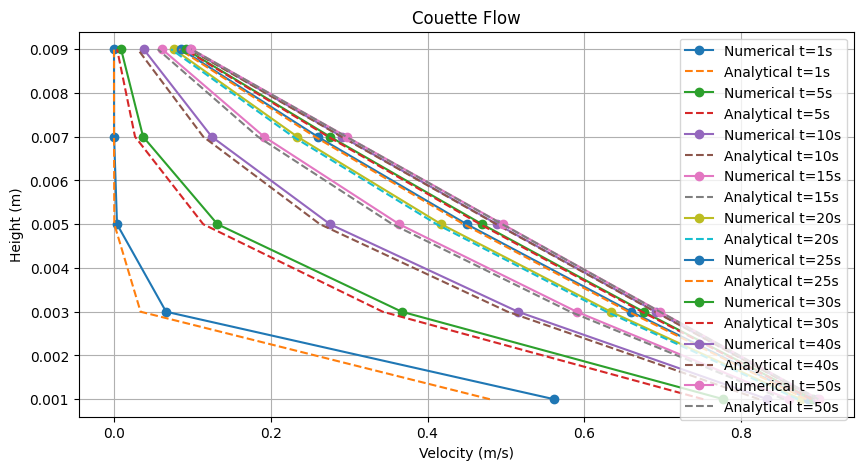


Percentage Error Table

Time (s) | Node | y (m)  | Numerical | Analytical | % Error
--------------------------------------------------------------
    1.0 |    1 | 0.0010 | 0.561468 | 0.479500 |  17.094
    1.0 |    2 | 0.0030 | 0.066420 | 0.033895 |  95.959
    1.0 |    3 | 0.0050 | 0.003845 | 0.000407 | 844.829
    1.0 |    4 | 0.0070 | 0.000110 | 0.000001 | 10925.690
    1.0 |    5 | 0.0090 | 0.000003 | 0.000000 | 249.980
--------------------------------------------------------------
    5.0 |    1 | 0.0010 | 0.777526 | 0.751830 |   3.418
    5.0 |    2 | 0.0030 | 0.367085 | 0.342782 |   7.090
    5.0 |    3 | 0.0050 | 0.131984 | 0.113844 |  15.934
    5.0 |    4 | 0.0070 | 0.037116 | 0.026817 |  38.403
    5.0 |    5 | 0.0090 | 0.009041 | 0.003922 | 130.511
--------------------------------------------------------------
   10.0 |    1 | 0.0010 | 0.833662 | 0.823044 |   1.290
   10.0 |    2 | 0.0030 | 0.515350 | 0.502191 |   2.620
   10.0 |    3 | 0.0050 | 0.275604 | 0.262756 |   4.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

time_list = [1,5,10,15,20,25,30,40,50]

t_max = max(time_list)

# -----------------------------------
# Physical parameters
# -----------------------------------
h = 0.01
U0 = 1.0
nu = 1e-6

# -----------------------------------
# Grid (5 CV centers)
# -----------------------------------
dy = h/5

y = np.array([
    dy/2,
    3*dy/2,
    5*dy/2,
    7*dy/2,
    9*dy/2
])

# -----------------------------------
# Time step
# -----------------------------------
dt = 0.2
A = nu*dt/dy**2

print("A =", A)

# -----------------------------------
# Analytical solution
# -----------------------------------
def analytical(y, t, terms=200):

    result = U0*(h-y)/h

    sum_term = np.zeros_like(y)

    for n in range(1, terms+1):

        sum_term += (
            (1/n)
            * np.sin(n*np.pi*y/h)
            * np.exp(-n**2*np.pi**2*nu*t/h**2)
        )

    result -= (2*U0/np.pi)*sum_term

    return result


# -----------------------------------
# Numerical solution using YOUR equations
# -----------------------------------
u_num = np.zeros(5)

profiles_num = {}
profiles_ana = {}

profiles_num[0] = u_num.copy()
profiles_ana[0] = analytical(y,0)

steps = int(t_max/dt)

for step in range(1, steps+1):
    u_old = u_num.copy()

    # bottom boundary node (moving plate)
    u_num[0] = (
        u_old[0]
        + 2*A*(u_old[1] - 3*u_old[0] + 2*U0)
    )

    # interior nodes
    u_num[1] = u_old[1] + A*(u_old[2] - 2*u_old[1] + u_old[0])
    u_num[2] = u_old[2] + A*(u_old[3] - 2*u_old[2] + u_old[1])
    u_num[3] = u_old[3] + A*(u_old[4] - 2*u_old[3] + u_old[2])

    # top boundary node (stationary plate)
    u_num[4] = (
        u_old[4]
        + 2*A*(u_old[3] - 3*u_old[4])
    )

    t = step*dt

    if any(abs(t - target) < 1e-12 for target in time_list):
        profiles_num[t] = u_num.copy()
        profiles_ana[t] = analytical(y,t)

# -----------------------------------
# Plot comparison
# -----------------------------------
plt.figure(figsize=(10,5))

for t in time_list:
    plt.plot(profiles_num[t],y,'o-',label=f"Numerical t={t}s")
    plt.plot(profiles_ana[t],y,'--',label=f"Analytical t={t}s")

plt.xlabel("Velocity (m/s)")
plt.ylabel("Height (m)")
plt.title("Couette Flow")
plt.legend()
plt.grid()
plt.show()


# -----------------------------------
# Error table
# -----------------------------------
print("\nPercentage Error Table\n")
print("Time (s) | Node | y (m)  | Numerical | Analytical | % Error")
print("--------------------------------------------------------------")

for t in time_list:
    num = profiles_num[t]
    ana = profiles_ana[t]

    for i in range(5):
        if abs(ana[i]) > 1e-12:
            error = abs((num[i]-ana[i])/max(ana[i], 1e-6))*100
        else:
            error = 0

        print(f"{t:7.1f} | {i+1:4d} | {y[i]:.4f} | "
              f"{num[i]:.6f} | {ana[i]:.6f} | {error:7.3f}")

    print("--------------------------------------------------------------")


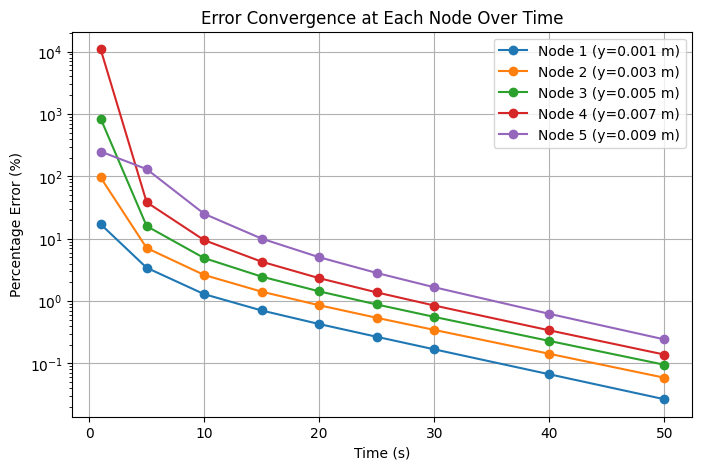

In [ ]:
errors = {i: [] for i in range(5)}
times = []

for t in time_list:

    num = profiles_num[t]
    ana = profiles_ana[t]

    times.append(t)

    for i in range(5):

        if abs(ana[i]) > 1e-12:
            error = abs((num[i] - ana[i]) / max(abs(ana[i]), 1e-6)) * 100
        else:
            error = 0

        errors[i].append(error)

# -----------------------------------
# Plot error trend
# -----------------------------------

plt.figure(figsize=(8,5))

for i in range(5):
    plt.plot(times, errors[i], marker='o', label=f'Node {i+1} (y={y[i]:.3f} m)')

plt.xlabel('Time (s)')
plt.ylabel('Percentage Error (%)')
plt.yscale('log')
plt.title('Error Convergence at Each Node Over Time')
plt.legend()
plt.grid(True)

plt.show()


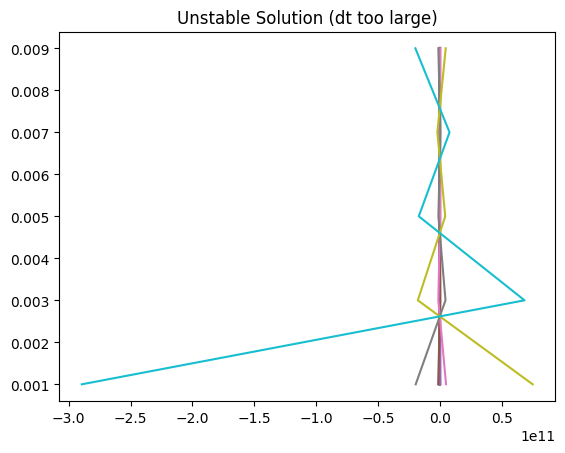

In [ ]:
# unstable test
dt_unstable = 3
A_unstable = nu*dt_unstable/dy**2

u = np.zeros(5)

history = []

for step in range(20):

    u_old = u.copy()

    u[0] = u_old[0] + 2*A_unstable*(u_old[1] - 3*u_old[0] + 2*U0)
    u[1] = u_old[1] + A_unstable*(u_old[2] - 2*u_old[1] + u_old[0])
    u[2] = u_old[2] + A_unstable*(u_old[3] - 2*u_old[2] + u_old[1])
    u[3] = u_old[3] + A_unstable*(u_old[4] - 2*u_old[3] + u_old[2])
    u[4] = u_old[4] + 2*A_unstable*(u_old[3] - 3*u_old[4])

    history.append(u.copy())

# plot
plt.figure()

for i in range(len(history)):
    plt.plot(history[i], y)

plt.title("Unstable Solution (dt too large)")
plt.show()


## Govering equations at each node for crank nicholson case

Coefficient definition:

$$
A =
\frac{\nu \Delta t}{(\Delta y)^2}
$$

For this problem:

$$
A = 0.25 \Delta t
$$

Crank–Nicolson corresponds to:

$$
\theta = \frac{1}{2}
$$

---

Node 1 equation (adjacent to moving plate):

$$
(1 + 3A) u_1^{n+1}
-
A u_2^{n+1}
=
(1 - 3A) u_1^n
+
A u_2^n
+
4A U_0
$$

Substitute numerical value of A and $U_0 = 1$:

$$
(1 + 0.75\Delta t) u_1^{n+1}
-
0.25\Delta t\, u_2^{n+1}
=
(1 - 0.75\Delta t) u_1^n
+
0.25\Delta t\, u_2^n
+
\Delta t
$$

---

Node 2 equation (interior node):

$$
(1 + A) u_2^{n+1}
-
\frac{A}{2} u_3^{n+1}
-
\frac{A}{2} u_1^{n+1}
=
(1 - A) u_2^n
+
\frac{A}{2} u_3^n
+
\frac{A}{2} u_1^n
$$

Substitute numerical value of A:

$$
(1 + 0.25\Delta t) u_2^{n+1}
-
0.125\Delta t\, u_3^{n+1}
-
0.125\Delta t\, u_1^{n+1}
=
(1 - 0.25\Delta t) u_2^n
+
0.125\Delta t\, u_3^n
+
0.125\Delta t\, u_1^n
$$

---

Node 3 equation (interior node):

$$
(1 + A) u_3^{n+1}
-
\frac{A}{2} u_4^{n+1}
-
\frac{A}{2} u_2^{n+1}
=
(1 - A) u_3^n
+
\frac{A}{2} u_4^n
+
\frac{A}{2} u_2^n
$$

Substitute numerical value of A:

$$
(1 + 0.25\Delta t) u_3^{n+1}
-
0.125\Delta t\, u_4^{n+1}
-
0.125\Delta t\, u_2^{n+1}
=
(1 - 0.25\Delta t) u_3^n
+
0.125\Delta t\, u_4^n
+
0.125\Delta t\, u_2^n
$$

---

Node 4 equation (interior node):

$$
(1 + A) u_4^{n+1}
-
\frac{A}{2} u_5^{n+1}
-
\frac{A}{2} u_3^{n+1}
=
(1 - A) u_4^n
+
\frac{A}{2} u_5^n
+
\frac{A}{2} u_3^n
$$

Substitute numerical value of A:

$$
(1 + 0.25\Delta t) u_4^{n+1}
-
0.125\Delta t\, u_5^{n+1}
-
0.125\Delta t\, u_3^{n+1}
=
(1 - 0.25\Delta t) u_4^n
+
0.125\Delta t\, u_5^n
+
0.125\Delta t\, u_3^n
$$

---

Node 5 equation (adjacent to stationary plate):

$$
(1 + 3A) u_5^{n+1}
-
A u_4^{n+1}
=
(1 - 3A) u_5^n
+
A u_4^n
$$

Substitute numerical value of A:

$$
(1 + 0.75\Delta t) u_5^{n+1}
-
0.25\Delta t\, u_4^{n+1}
=
(1 - 0.75\Delta t) u_5^n
+
0.25\Delta t\, u_4^n
$$


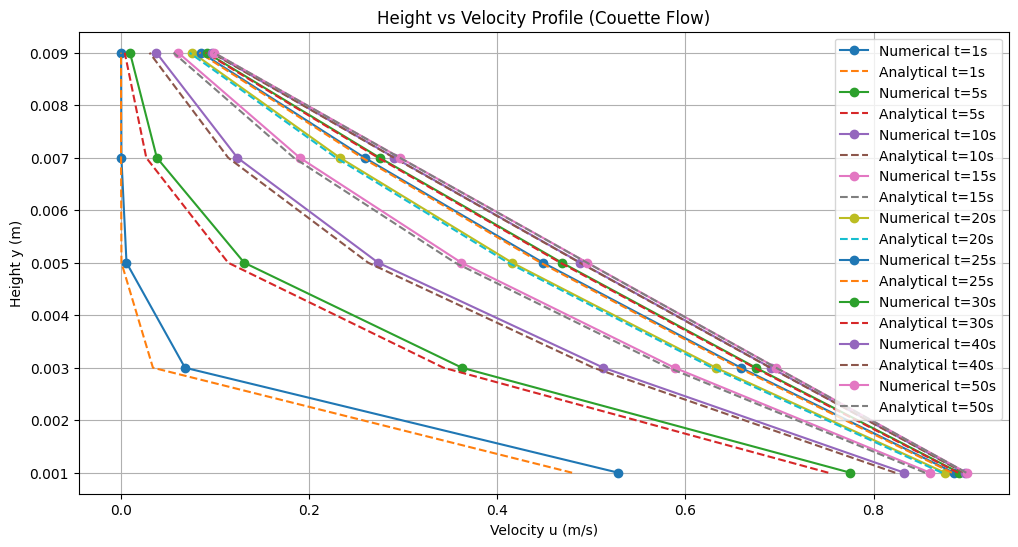


Percentage Error Table

Time (s) | Node | y (m)  | Numerical | Analytical | % Error
--------------------------------------------------------------
    1.0 |    1 | 0.0010 | 0.528679 | 0.479500 |  10.256
    1.0 |    2 | 0.0030 | 0.067954 | 0.033895 | 100.485
    1.0 |    3 | 0.0050 | 0.005791 | 0.000407 | 1323.007
    1.0 |    4 | 0.0070 | 0.000379 | 0.000001 | 37817.578
    1.0 |    5 | 0.0090 | 0.000034 | 0.000000 | 3444.859
--------------------------------------------------------------
    5.0 |    1 | 0.0010 | 0.775285 | 0.751830 |   3.120
    5.0 |    2 | 0.0030 | 0.362345 | 0.342782 |   5.707
    5.0 |    3 | 0.0050 | 0.130941 | 0.113844 |  15.017
    5.0 |    4 | 0.0070 | 0.038050 | 0.026817 |  41.885
    5.0 |    5 | 0.0090 | 0.009495 | 0.003922 | 142.084
--------------------------------------------------------------
   10.0 |    1 | 0.0010 | 0.832657 | 0.823044 |   1.168
   10.0 |    2 | 0.0030 | 0.512753 | 0.502191 |   2.103
   10.0 |    3 | 0.0050 | 0.273398 | 0.262756 |   

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Physical parameters
# -----------------------------------

h   = 0.01
U0  = 1.0
mu  = 1e-3
rho = 1000

nu = mu/rho

# -----------------------------------
# Grid
# -----------------------------------

N  = 5
dy = h/N

y = np.array([(i+0.5)*dy for i in range(N)])

# -----------------------------------
# Time parameters
# -----------------------------------

dt    = 0.2
steps = int(t_max/dt)

# -----------------------------------
# Crank–Nicolson coefficient
# -----------------------------------

A = nu*dt/(dy**2)

# -----------------------------------
# Initial condition
# -----------------------------------

u_num = np.zeros(N)

# storage
profiles_cn = {}
profiles_ana = {}

# -----------------------------------
# Build constant matrix M
# -----------------------------------

M = np.zeros((N,N))

# moving plate boundary
M[0,0] = 1 + 3*A
M[0,1] = -A

# interior nodes
for i in range(1,N-1):

    M[i,i]   = 1 + A
    M[i,i-1] = -A/2
    M[i,i+1] = -A/2

# static plate boundary
M[N-1,N-1] = 1 + 3*A
M[N-1,N-2] = -A

# -----------------------------------
# Time loop
# -----------------------------------

for step in range(1,steps+1):

    u_old = u_num.copy()

    R = np.zeros((N,N))
    b = np.zeros(N)

    # moving plate boundary
    R[0,0] = 1 - 3*A
    R[0,1] = A
    b[0]   = 4*A*U0

    # interior nodes
    for i in range(1,N-1):

        R[i,i]   = 1 - A
        R[i,i-1] = A/2
        R[i,i+1] = A/2

    # static plate boundary
    R[N-1,N-1] = 1 - 3*A
    R[N-1,N-2] = A

    rhs = R @ u_old + b

    # solve system
    u_num = np.linalg.solve(M, rhs)

    t = step*dt

    if t in time_list:

        profiles_cn[t] = u_num.copy()
        profiles_ana[t] = analytical(y,t)

# -----------------------------------
# Height vs Velocity plot
# -----------------------------------

plt.figure(figsize=(12,6))

for t in time_list:

    num = profiles_cn[t]
    ana = profiles_ana[t]

    plt.plot(num, y, 'o-', label=f'Numerical t={t}s')
    plt.plot(ana, y, '--', label=f'Analytical t={t}s')

plt.xlabel('Velocity u (m/s)')
plt.ylabel('Height y (m)')
plt.title('Height vs Velocity Profile (Couette Flow)')
plt.legend()
plt.grid()

plt.show()


# -----------------------------------
# Error table
# -----------------------------------
print("\nPercentage Error Table\n")
print("Time (s) | Node | y (m)  | Numerical | Analytical | % Error")
print("--------------------------------------------------------------")

for t in time_list:
    num = profiles_cn[t]
    ana = profiles_ana[t]

    for i in range(5):
        if abs(ana[i]) > 1e-12:
            error = abs((num[i]-ana[i])/max(ana[i], 1e-6))*100
        else:
            error = 0

        print(f"{t:7.1f} | {i+1:4d} | {y[i]:.4f} | "
              f"{num[i]:.6f} | {ana[i]:.6f} | {error:7.3f}")

    print("--------------------------------------------------------------")


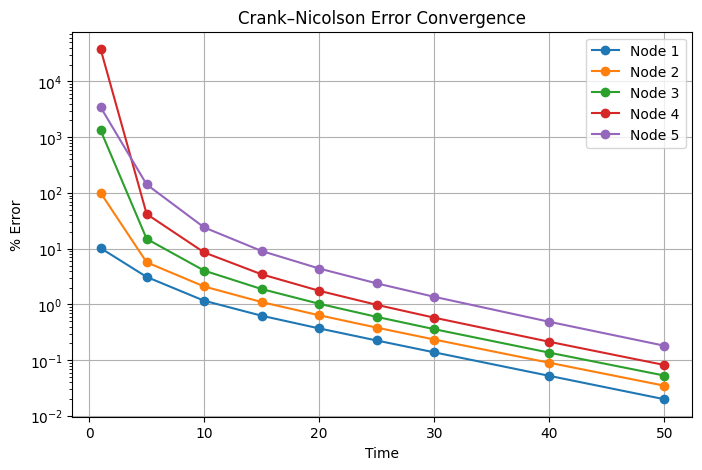

In [ ]:
# -----------------------------------
# Error plot
# -----------------------------------

errors = {i: [] for i in range(N)}
times  = []

for t in time_list:

    num = profiles_cn[t]
    ana = profiles_ana[t]

    times.append(t)

    for i in range(N):

        if abs(ana[i]) > 1e-12:
            error = abs(num[i]-ana[i])/max(abs(ana[i]),1e-6)*100
        else:
            error = 0

        errors[i].append(error)

plt.figure(figsize=(8,5))

for i in range(N):

    plt.plot(times, errors[i], marker='o', label=f'Node {i+1}')

plt.xlabel('Time')
plt.ylabel('% Error')
plt.yscale('log')
plt.title('Crank–Nicolson Error Convergence')
plt.legend()
plt.grid()


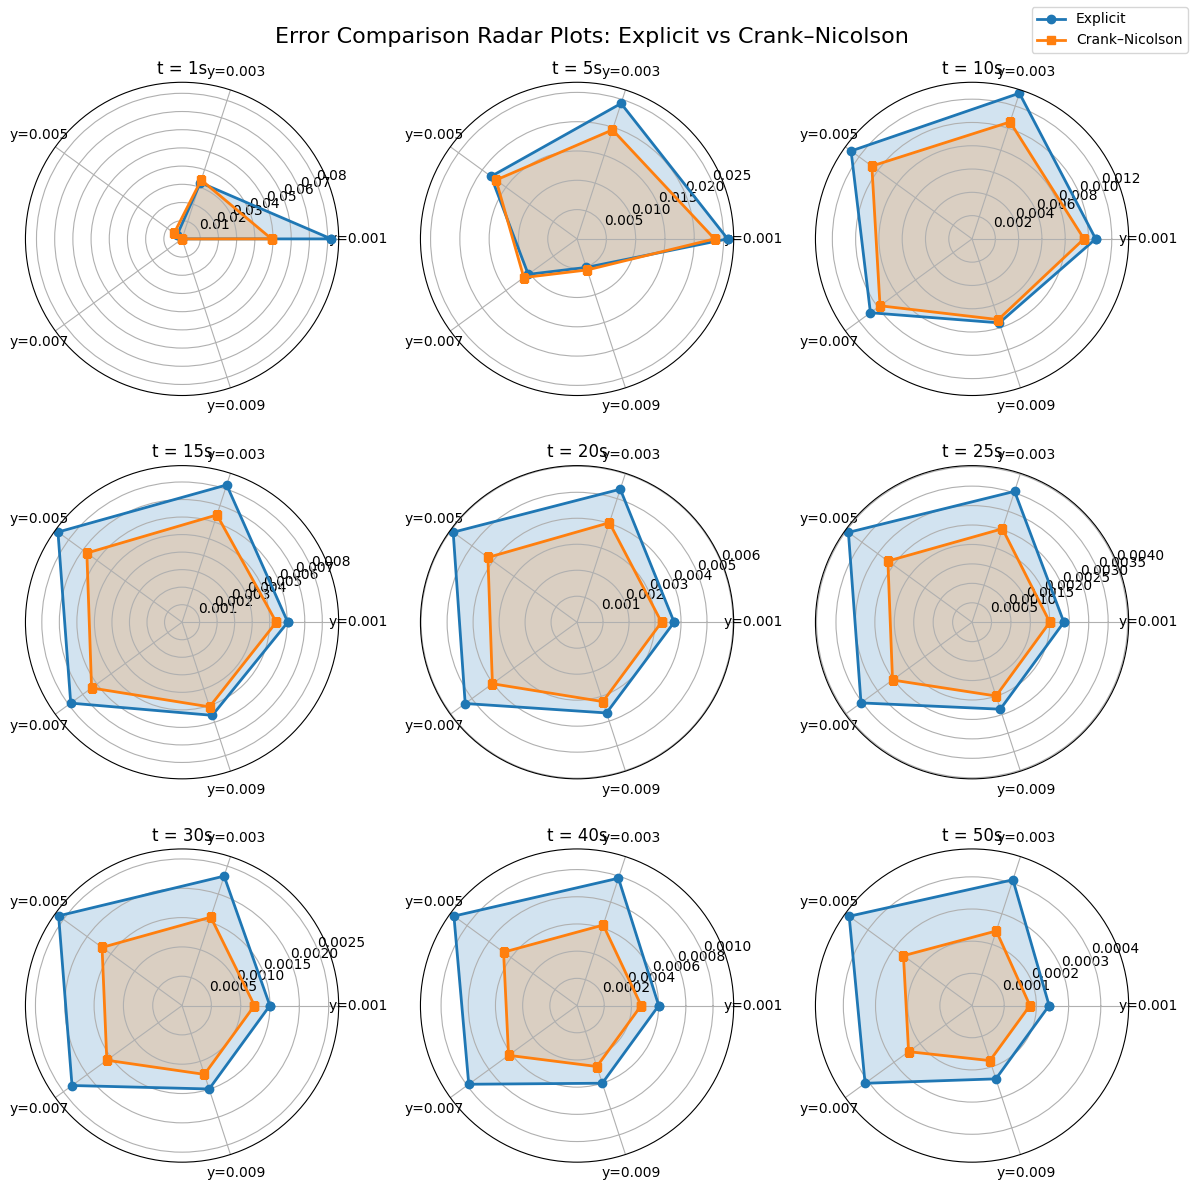

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Radar plot grid (3x3)
# -----------------------------------

labels = [f'y={yy:.3f}' for yy in y]
N = len(labels)

angles = np.linspace(0, 2*np.pi, N, endpoint=False)
angles = np.append(angles, angles[0])

fig, axes = plt.subplots(3, 3, figsize=(12,12), subplot_kw=dict(polar=True))

axes = axes.flatten()

for idx, t in enumerate(time_list):

    exp = profiles_num[t]
    cn  = profiles_cn[t]
    ana = profiles_ana[t]

    error_exp = np.abs(exp - ana)
    error_cn  = np.abs(cn  - ana)

    error_exp = np.append(error_exp, error_exp[0])
    error_cn  = np.append(error_cn,  error_cn[0])

    ax = axes[idx]

    ax.plot(angles, error_exp, 'o-', linewidth=2, label='Explicit')
    ax.fill(angles, error_exp, alpha=0.2)

    ax.plot(angles, error_cn, 's-', linewidth=2, label='Crank–Nicolson')
    ax.fill(angles, error_cn, alpha=0.2)

    ax.set_thetagrids(angles[:-1]*180/np.pi, labels)

    ax.set_title(f't = {t}s')

# hide unused subplot if only 8 times
if len(time_list) < 9:
    axes[-1].axis('off')

# global legend
handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc='upper right')

plt.suptitle('Error Comparison Radar Plots: Explicit vs Crank–Nicolson', fontsize=16)

plt.tight_layout()
plt.show()
